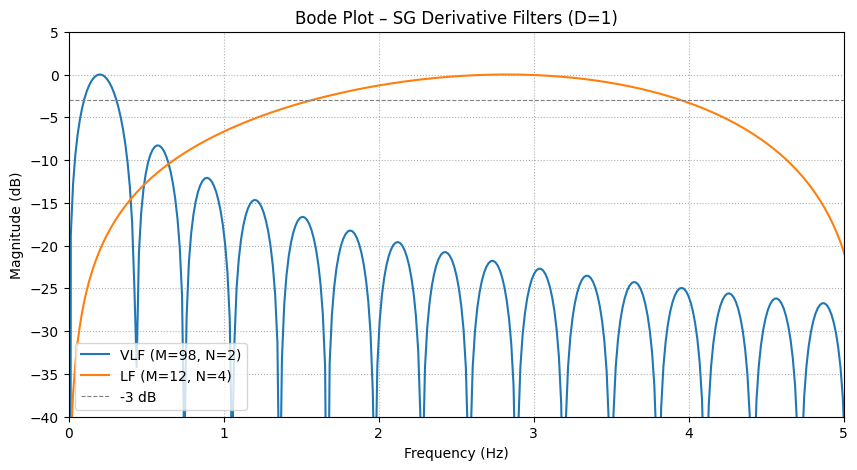

In [41]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_coeffs


VLF_PARAMS=(98, 2)
LF_PARAMS=(12, 4)

D = 1
vlf_wl = VLF_PARAMS[0] * 2 + 1
lf_wl = LF_PARAMS[0] * 2 + 1
vlf_coeffs = savgol_coeffs(window_length=vlf_wl, polyorder=VLF_PARAMS[1], deriv=D)
lf_coeffs = savgol_coeffs(window_length=lf_wl, polyorder=LF_PARAMS[1], deriv=D)

freqs_vlf, mag_vlf = _freq_response(vlf_coeffs)
freqs_lf, mag_lf = _freq_response(lf_coeffs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(freqs_vlf, mag_vlf, label=f"VLF (M={VLF_PARAMS[0]}, N={VLF_PARAMS[1]})")
ax.plot(freqs_lf, mag_lf, label=f"LF (M={LF_PARAMS[0]}, N={LF_PARAMS[1]})")
ax.axhline(-3, color="gray", linestyle="--", linewidth=0.8, label="-3 dB")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude (dB)")
ax.set_title("Bode Plot – SG Derivative Filters (D=1)")
ax.set_xlim(0, 5)
ax.set_ylim(-40, 5)
ax.legend()
ax.grid(True, which="both", linestyle=":")
plt.show()

In [37]:
import numpy as np
import pandas as pd
def _freq_response(coeffs, n_fft=4096, fs=60):
    """Return (freqs, magnitude_dB) for an FIR filter."""
    H = np.fft.rfft(coeffs, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1.0 / fs)
    mag = np.abs(H)
    # Normalise so peak = 0 dB
    mag /= mag.max() + 1e-30
    mag_db = 20 * np.log10(mag + 1e-30)
    return freqs, mag_db

def _make_pupil_df(signal: np.ndarray) -> pd.DataFrame:
    """Wrap a 1-D signal array into a DataFrame with the expected column."""
    return pd.DataFrame({"pupil_diameter": signal})


def _make_sine_signal(freq_hz: float, duration_s: float = 10.0, fs: int = 60):
    t = np.arange(0, duration_s, 1.0 / fs)
    return t, np.sin(2 * np.pi * freq_hz * t) + 5

In [17]:
from cognitive_models.pupil_utils import ripa2

_, sig = _make_sine_signal(0.05, duration_s=30.0)
df = _make_pupil_df(sig)
ripa2(df, VLF=VLF_PARAMS, LF=LF_PARAMS, n_out=1)

np.float64(6.401878651364562e-07)

([<matplotlib.axis.XTick at 0x27086964550>,
 [Text(0.0, 0, '0.0'),
  Text(0.5, 0, '0.5'),
  Text(1.0, 0, '1.0'),
  Text(1.5, 0, '1.5'),
  Text(2.0, 0, '2.0'),
  Text(2.5, 0, '2.5'),
  Text(3.0, 0, '3.0'),
  Text(3.5, 0, '3.5'),
  Text(4.0, 0, '4.0'),
  Text(4.5, 0, '4.5'),
  Text(5.0, 0, '5.0'),
  Text(5.5, 0, '5.5'),
  Text(6.0, 0, '6.0'),
  Text(6.5, 0, '6.5'),
  Text(7.0, 0, '7.0'),
  Text(7.5, 0, '7.5'),
  Text(8.0, 0, '8.0'),
  Text(8.5, 0, '8.5'),
  Text(9.0, 0, '9.0'),
  Text(9.5, 0, '9.5')])

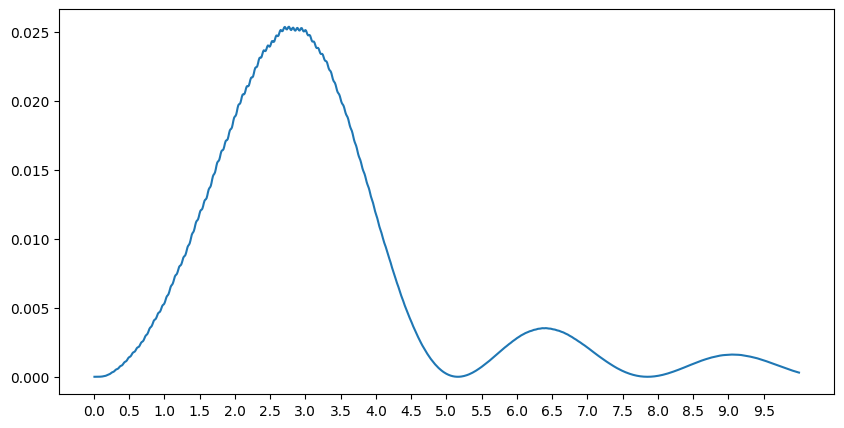

In [38]:
freq_sweep = np.linspace(0.01, 10, num=1000)
response = []
for freq in freq_sweep:
    _, sig = _make_sine_signal(freq, duration_s=10.0)
    df = _make_pupil_df(sig)
    response.append(ripa2(df, VLF=VLF_PARAMS, LF=LF_PARAMS, n_out=1))
response = np.array(response).flatten()
plt.figure(figsize=(10, 5))
plt.plot(freq_sweep, response)
plt.xticks(np.arange(0, 10, 0.5))
